# Brain Tumor MRI Classification — GCN Task 3 (Robust Rewrite)

This notebook rebuilds the Task 3 GCN pipeline around the two findings that
Task 3's own ablation surfaced:

1. **Features were the bottleneck, not the graph.** Swapping 5 hand-crafted
   node stats for *frozen* ResNet18 features took accuracy from 75.8% to
   89.4% before the GCN even ran — a 13+ point jump from features alone.
2. **The graph's contribution was inconclusive, not proven negative.**
   CNN+GCN beat CNN-only by 1.4 points but p=0.243 — underpowered, not
   disproven. Plain `GCNConv` with weak edge/pooling design was never given
   a fair shot.

This rewrite acts on both:

- **Features**: CNN backbone features per superpixel, with the **last
  backbone block fine-tuned end-to-end** (not frozen) so features adapt to
  MRI texture instead of staying generic ImageNet features.
- **Graph structure gets more to do**: richer edge features (intensity
  diff, shared-boundary length, centroid distance, texture similarity), a
  **virtual global node** connected to every superpixel for whole-image
  context, and a **configurable conv type** (`GCNConv` vs `GATConv`) so
  attention-weighted neighbor aggregation is actually tried.
- **Better pooling**: attention pooling concatenated with mean+max, so the
  model can learn which superpixels matter for the final decision.
- **Regularization built for graphs**: node-feature noise + edge dropout as
  graph-level augmentation, plus class-balanced sampling (not just loss
  reweighting).
- Everything else (dedup/leakage removal, CV protocol, McNemar tests,
  explainability, ablation) is kept identical to Task 3 so results stay
  comparable.

## Table of Contents
1. [Setup & Configuration](#1-setup)
2. [File Index & Deduplication (16x16 Hash)](#2-dedup)
3. [Image to Graph Conversion — CNN Features, Rich Edges, Virtual Node](#3-graph)
4. [Robust, Configurable GCN/GAT with Attention Pooling](#4-model)
5. [Training Utilities — Graph Augmentation, Balanced Sampling](#5-train-utils)
6. [Config Sweep — conv type, fine-tuning depth, edges, pooling, augmentation](#6-sweep)
7. [5-Fold CV with Best Config](#7-cv)
8. [Final Model — Train & Evaluate on Held-Out Test](#8-final)
9. [Significance Test vs Best Baseline (ViT)](#9-significance)
10. [Explainability — GNNExplainer, Superpixel Grad-CAM, Superpixel LIME](#10-xai)
11. [Ablation — CNN vs CNN+GCN (repeated, on the new pipeline)](#11-ablation)
12. [Results Summary](#12-summary)


## 1. Setup & Configuration

In [1]:
!pip install -q torch_geometric scikit-image

import os, json, time, copy, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import (
    GCNConv, GATv2Conv, global_mean_pool, global_max_pool,
    global_add_pool,
)
from torch_geometric.explain import Explainer, GNNExplainer

from torchvision.models import resnet18, ResNet18_Weights

from skimage.segmentation import slic
from skimage.graph import rag_mean_color
from skimage.measure import regionprops

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_fscore_support, accuracy_score,
)
from sklearn.utils.class_weight import compute_class_weight
from statsmodels.stats.contingency_tables import mcnemar

sns.set_style("whitegrid")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATA_DIR = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "Training")
TEST_DIR = os.path.join(DATA_DIR, "Testing")
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

GRAPH_IMG_SIZE = (128, 128)
N_SEGMENTS = 75
BATCH_SIZE = 32

PATIENCE = 6
MIN_EPOCHS = 50
MAX_EPOCHS = 60
WEIGHT_DECAY = 1e-4
N_FOLDS = 5

SWEEP_MIN_EPOCHS = 15
SWEEP_MAX_EPOCHS = 30

# Backbone feature dim: features are pooled from ResNet18's layer2 output.
CNN_FEATURE_DIM = 128

# Graph-augmentation defaults (see Section 5) -- light regularization applied
# only during training, never at eval/test time.
NODE_NOISE_STD = 0.02
EDGE_DROPOUT_P = 0.1

CACHE_DIR = "/kaggle/working/graph_cache_task4"
os.makedirs(CACHE_DIR, exist_ok=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 57.6 MB/s eta 0:00:00
Device: cuda


## 2. File Index & Deduplication (16x16 Hash)

Unchanged from Task 3 — this part was already correct and isn't where the accuracy problem lived.

In [2]:
def build_index(root_dir, split_name):
    records = []
    for cls in CLASSES:
        cls_dir = os.path.join(root_dir, cls)
        for fname in os.listdir(cls_dir):
            records.append({"filepath": os.path.join(cls_dir, fname), "class": cls, "split": split_name})
    return pd.DataFrame(records)

def phash_16x16(filepath):
    img = Image.open(filepath).convert("L").resize((16, 16), Image.LANCZOS)
    pixels = np.asarray(img, dtype=np.float32)
    avg = pixels.mean()
    bits = (pixels > avg).flatten()
    return "".join("1" if b else "0" for b in bits)

def dedup_within_split(df, split_name):
    before = len(df)
    df_sorted = df.sort_values("filepath").reset_index(drop=True)
    df_deduped = df_sorted.drop_duplicates(subset="phash16", keep="first").reset_index(drop=True)
    print(f"{split_name}: removed {before - len(df_deduped)} within-split duplicate(s) ({before} -> {len(df_deduped)})")
    return df_deduped

def remove_leakage(df_reference, df_target, ref_name, target_name):
    ref_hashes = set(df_reference["phash16"])
    before = len(df_target)
    mask = df_target["phash16"].isin(ref_hashes)
    df_clean = df_target[~mask].reset_index(drop=True)
    print(f"{ref_name} -> {target_name}: removed {mask.sum()} leaked image(s) ({before} -> {len(df_clean)})")
    return df_clean

df_train_full = build_index(TRAIN_DIR, "train")
df_test_full = build_index(TEST_DIR, "test")
df_val, df_test = train_test_split(df_test_full, test_size=0.5, stratify=df_test_full["class"], random_state=SEED)
df_train = df_train_full.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train["phash16"] = df_train["filepath"].apply(phash_16x16)
df_val["phash16"] = df_val["filepath"].apply(phash_16x16)
df_test["phash16"] = df_test["filepath"].apply(phash_16x16)

df_train = dedup_within_split(df_train, "train")
df_val = dedup_within_split(df_val, "val")
df_test = dedup_within_split(df_test, "test")

df_val = remove_leakage(df_train, df_val, "train", "val")
df_test = remove_leakage(df_train, df_test, "train", "test")
df_test = remove_leakage(df_val, df_test, "val", "test")

df_train["class_idx"] = df_train["class"].map(CLASS_TO_IDX)
df_val["class_idx"] = df_val["class"].map(CLASS_TO_IDX)
df_test["class_idx"] = df_test["class"].map(CLASS_TO_IDX)

df_trainval = pd.concat([df_train, df_val], ignore_index=True)

print(f"\nFinal sizes -> train+val (for CV): {df_trainval.shape} | held-out test: {df_test.shape}")


train: removed 559 within-split duplicate(s) (5600 -> 5041)
val: removed 30 within-split duplicate(s) (800 -> 770)
test: removed 37 within-split duplicate(s) (800 -> 763)
train -> val: removed 159 leaked image(s) (770 -> 611)
train -> test: removed 169 leaked image(s) (763 -> 594)
val -> test: removed 19 leaked image(s) (594 -> 575)

Final sizes -> train+val (for CV): (5652, 5) | held-out test: (575, 5)


## 3. Image to Graph Conversion — CNN Features, Rich Edges, Virtual Node

This section replaces Task 3's hand-crafted 5-feature nodes with **fine-tunable
CNN features**, and gives the graph itself more informative structure:

**Node features (128-d):** ResNet18 (ImageNet-pretrained) up to `layer2`,
average-pooled per superpixel. Unlike Task 3's ablation, the **last backbone
block (`layer2`) stays trainable** — it's fine-tuned jointly with the GCN,
not frozen. Everything before it stays frozen (low-level filters transfer
fine; that's standard transfer-learning practice, and it keeps the parameter
count / overfit risk down for a ~5.6k-image dataset).

**Edge features (4-d, up from 1):**
1. mean-intensity difference (Task 3's original signal)
2. shared-boundary length between adjacent superpixels (normalized) — two
   regions sharing a long border are more likely part of the same structure
   than two that barely touch
3. centroid distance (normalized) — spatial proximity
4. texture similarity: difference in intensity std-dev between regions

**Virtual global node:** one extra node per graph, connected to every
superpixel, initialized as the mean of all real node features. Lets the GCN
mix in whole-image context in a single hop instead of relying on many
message-passing layers to propagate information across a ~60-node graph.

Because the backbone is fine-tuned, graphs can't be fully precomputed and
cached the way Task 3's hand-crafted graphs were — the *segments/edges*
(structure) are cached, but node features are computed by a live,
trainable backbone at forward time.


In [3]:
# --- Backbone: frozen up to layer1, trainable layer2 (fine-tuned jointly with the GCN) ---
_resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
# children(): conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool, fc
_backbone_children = list(_resnet.children())
FROZEN_STEM = nn.Sequential(*_backbone_children[:5])   # conv1..layer1 -- stays frozen
TRAINABLE_BLOCK = _backbone_children[5]                 # layer2 -- fine-tuned end-to-end

for p in FROZEN_STEM.parameters():
    p.requires_grad = False
for p in TRAINABLE_BLOCK.parameters():
    p.requires_grad = True

FROZEN_STEM = FROZEN_STEM.to(device).eval()
TRAINABLE_BLOCK = TRAINABLE_BLOCK.to(device)

IMAGENET_MEAN_T = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
IMAGENET_STD_T = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)


def backbone_feature_map(img_tensor, train_mode):
    '''img_tensor: (B,1,H,W) in [0,1]. Returns (B,128,h,w) feature map.
    Stem is always frozen/eval (no grad); trainable block follows train_mode.'''
    t = img_tensor.repeat(1, 3, 1, 1)
    t = (t - IMAGENET_MEAN_T) / IMAGENET_STD_T
    with torch.no_grad():
        stem_out = FROZEN_STEM(t)
    TRAINABLE_BLOCK.train(train_mode)
    fmap = TRAINABLE_BLOCK(stem_out)
    return fmap  # (B, 128, H/8, W/8)


# --- Graph *structure* (segments + rich edges) is precomputed & cached; node
# features are filled in at forward time by the (trainable) backbone. ---
def image_to_graph_structure(filepath, label_idx, n_segments=N_SEGMENTS):
    img = Image.open(filepath).convert("L").resize(GRAPH_IMG_SIZE, Image.LANCZOS)
    img_arr = np.asarray(img, dtype=np.float32) / 255.0
    img_rgb = np.stack([img_arr] * 3, axis=-1)

    segments = slic(img_rgb, n_segments=n_segments, compactness=10, start_label=0, channel_axis=-1)
    n_nodes = segments.max() + 1
    H, W = img_arr.shape

    # Hand-crafted per-node stats kept ONLY for edge-feature construction
    # (texture similarity, centroid distance) -- not used as model input.
    node_mean = np.zeros(n_nodes, dtype=np.float32)
    node_std = np.zeros(n_nodes, dtype=np.float32)
    node_cx = np.zeros(n_nodes, dtype=np.float32)
    node_cy = np.zeros(n_nodes, dtype=np.float32)
    node_size = np.zeros(n_nodes, dtype=np.float32)
    for seg_id in range(n_nodes):
        mask = segments == seg_id
        ys, xs = np.where(mask)
        pixels = img_arr[mask]
        node_mean[seg_id] = pixels.mean()
        node_std[seg_id] = pixels.std()
        node_cx[seg_id] = xs.mean() / W
        node_cy[seg_id] = ys.mean() / H
        node_size[seg_id] = mask.sum()

    # Shared-boundary length: count adjacent-pixel pairs across each edge.
    boundary_len = {}
    right_diff = segments[:, :-1] != segments[:, 1:]
    for y, x in zip(*np.where(right_diff)):
        a, b = int(segments[y, x]), int(segments[y, x + 1])
        key = (min(a, b), max(a, b))
        boundary_len[key] = boundary_len.get(key, 0) + 1
    down_diff = segments[:-1, :] != segments[1:, :]
    for y, x in zip(*np.where(down_diff)):
        a, b = int(segments[y, x]), int(segments[y + 1, x])
        key = (min(a, b), max(a, b))
        boundary_len[key] = boundary_len.get(key, 0) + 1
    max_boundary = max(boundary_len.values()) if boundary_len else 1

    rag = rag_mean_color(img_rgb, segments)
    edge_index, edge_attr = [], []
    diag = float(np.hypot(W, H))
    for u, v, _ in rag.edges(data=True):
        intensity_diff = abs(node_mean[u] - node_mean[v])
        blen = boundary_len.get((min(u, v), max(u, v)), 0) / max_boundary
        cdist = float(np.hypot(node_cx[u] - node_cx[v], node_cy[u] - node_cy[v]))
        texture_diff = abs(node_std[u] - node_std[v])
        feat = [intensity_diff, blen, cdist, texture_diff]
        edge_index.append([u, v]); edge_attr.append(feat)
        edge_index.append([v, u]); edge_attr.append(feat)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous().cpu()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float32).cpu()
    y = torch.tensor([label_idx], dtype=torch.long).cpu()

    return dict(
        segments=segments, filepath=filepath, y=y, n_nodes=n_nodes,
        edge_index=edge_index, edge_attr=edge_attr,
        # kept for reference / explainability plots only:
        node_mean=node_mean, node_size=node_size,
    )


def build_structure_list(df, cache_name, n_segments=N_SEGMENTS):
    cache_path = os.path.join(CACHE_DIR, cache_name)
    if os.path.exists(cache_path):
        print(f"Loading cached structures from {cache_path}...")
        return torch.load(cache_path, weights_only=False)
    print(f"Building {len(df)} graph structures for {cache_name}...")
    out = []
    for i, row in df.iterrows():
        out.append(image_to_graph_structure(row["filepath"], row["class_idx"], n_segments=n_segments))
        if (i + 1) % 500 == 0:
            print(f"  {i + 1}/{len(df)} done")
    torch.save(out, cache_path)
    print(f"Cached to {cache_path}")
    return out


ADD_VIRTUAL_NODE = True  # winner is confirmed/overridden by Section 6's sweep

def add_virtual_node(edge_index, edge_attr, n_nodes):
    '''Appends one virtual node (index n_nodes) connected to every real node
    both ways. Virtual-node edges get a distinct 5th edge-feature dim (all
    zeros for real-real edges, 1 for any edge touching the virtual node) so
    the model can tell "global context" edges apart from local ones.'''
    real_marker = torch.zeros(edge_attr.shape[0], 1)
    edge_attr = torch.cat([edge_attr, real_marker], dim=1)

    vnode = n_nodes
    vs = torch.arange(n_nodes, dtype=torch.long)
    fwd = torch.stack([vs, torch.full_like(vs, vnode)], dim=0)
    bwd = torch.stack([torch.full_like(vs, vnode), vs], dim=0)
    v_edge_index = torch.cat([fwd, bwd], dim=1)
    v_feat = torch.zeros(v_edge_index.shape[1], edge_attr.shape[1])
    v_feat[:, -1] = 1.0

    new_edge_index = torch.cat([edge_index, v_edge_index], dim=1)
    new_edge_attr = torch.cat([edge_attr, v_feat], dim=0)
    return new_edge_index, new_edge_attr, n_nodes + 1


def structure_to_pyg_data(struct, add_virtual=ADD_VIRTUAL_NODE):
    '''Builds a PyG Data object with a placeholder `x`; real features get
    filled in by `featurize_batch` right before the forward pass (since the
    backbone is trainable, features can't be precomputed once).'''
    n_nodes = struct["n_nodes"]
    edge_index, edge_attr = struct["edge_index"], struct["edge_attr"]
    if add_virtual:
        edge_index, edge_attr, n_nodes = add_virtual_node(edge_index, edge_attr, n_nodes)
    else:
        edge_attr = torch.cat([edge_attr, torch.zeros(edge_attr.shape[0], 1)], dim=1)
    x_placeholder = torch.zeros(n_nodes, CNN_FEATURE_DIM)  # filled at forward time
    data = Data(x=x_placeholder, edge_index=edge_index, edge_attr=edge_attr, y=struct["y"])
    data.filepath = struct["filepath"]
    data.segments = struct["segments"]
    data.n_real_nodes = int(struct["n_nodes"])  # plain python int, not numpy int64 --
    # avoids ambiguous PyG batching behavior for custom scalar attributes
    data.has_virtual = add_virtual
    return data


@torch.no_grad()
def _featurize_one_eval(filepath, segments, n_real_nodes, has_virtual):
    '''Frozen-mode featurization (used for quick structure checks only;
    the real training path featurizes per-batch in train_mode, see Sec. 5).'''
    img = Image.open(filepath).convert("L").resize(GRAPH_IMG_SIZE, Image.LANCZOS)
    img_arr = np.asarray(img, dtype=np.float32) / 255.0
    t = torch.tensor(img_arr).unsqueeze(0).unsqueeze(0).to(device)
    fmap = backbone_feature_map(t, train_mode=False)[0]
    fh, fw = fmap.shape[1], fmap.shape[2]
    seg_small = np.array(Image.fromarray(segments.astype(np.int32)).resize((fw, fh), Image.NEAREST))
    fmap_np = fmap.cpu().numpy()
    feats = np.zeros((n_real_nodes, CNN_FEATURE_DIM), dtype=np.float32)
    for seg_id in range(n_real_nodes):
        mask = seg_small == seg_id
        feats[seg_id] = fmap_np[:, mask].mean(axis=1) if mask.sum() > 0 else fmap_np.reshape(CNN_FEATURE_DIM, -1).mean(axis=1)
    if has_virtual:
        feats = np.concatenate([feats, feats.mean(axis=0, keepdims=True)], axis=0)
    return feats


struct_trainval = build_structure_list(df_trainval, "trainval_structs.pt")
struct_test = build_structure_list(df_test, "test_structs.pt")

graphs_trainval = [structure_to_pyg_data(s) for s in struct_trainval]
graphs_test = [structure_to_pyg_data(s) for s in struct_test]

avg_nodes = np.mean([g.n_real_nodes for g in graphs_trainval])
print(f"\nAvg real nodes/graph: {avg_nodes:.1f} (+1 virtual node each)")
print(f"Edge feature dim: {graphs_trainval[0].edge_attr.shape[1]} (was 1 for Task 3's plain intensity-diff)")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


Building 5652 graph structures for trainval_structs.pt...
  500/5652 done
  1000/5652 done
  1500/5652 done
  2000/5652 done
  2500/5652 done
  3000/5652 done
  3500/5652 done
  4000/5652 done
  4500/5652 done
  5000/5652 done
  5500/5652 done
Cached to /kaggle/working/graph_cache_task4/trainval_structs.pt
Building 575 graph structures for test_structs.pt...
  500/575 done
Cached to /kaggle/working/graph_cache_task4/test_structs.pt

Avg real nodes/graph: 61.3 (+1 virtual node each)
Edge feature dim: 5 (was 1 for Task 3's plain intensity-diff)


## 4. Robust, Configurable GCN/GAT with Attention Pooling

Two structural changes from Task 3's model, both directly motivated by the
inconclusive CNN+GCN vs CNN-only ablation (p=0.243):

- **`conv_type` is now a real switch between `gcn` (`GCNConv`) and `gat`
  (`GATv2Conv`, edge-feature-aware, multi-head attention).** Task 3
  explicitly never tried attention-based aggregation. GAT lets each node
  weight its neighbors instead of averaging them uniformly, which matters
  more now that nodes carry rich 128-d CNN features and edges carry 5-d
  structural features instead of a single scalar.
- **Attention pooling is concatenated with mean+max pooling** (via a small
  gated-attention readout over final node embeddings) so the graph-level
  representation can down-weight uninformative superpixels (background,
  skull) instead of averaging them in with equal weight.

The virtual node (Section 3) means the last layer's node embeddings already
carry a whole-image summary that every node has 1-hop access to, which is
also what lets a shallower/lighter GCN work without needing many
message-passing layers to reach global context.


In [4]:
def gcn_edge_weight(edge_attr):
    '''Shared edge-weight transform for the GCNConv fallback path (GATv2Conv
    consumes the full edge_attr directly and doesn't need this).

    edge_attr[:, 0] stores intensity DIFFERENCE, not similarity -- feeding it
    to GCNConv's edge_weight directly would be backwards (GCN treats a higher
    edge_weight as "trust this edge more", so dissimilar regions would get
    amplified and near-identical ones suppressed) and would give every
    virtual-node edge zero weight (their diff feature is 0 by construction),
    silencing the virtual node whenever conv_type="gcn" is selected. Convert
    to a similarity score instead: 1/(1+diff) is in (0, 1], highest for
    similar/virtual edges, lowest for very different regions.'''
    return 1.0 / (1.0 + edge_attr[:, 0])


class AttentionPool(nn.Module):
    '''Gated-attention readout (Ilse et al., 2018 style): learns a scalar
    importance score per node, softmax-normalized within each graph, then
    returns the weighted sum of node embeddings.'''
    def __init__(self, in_channels, hidden=64):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(in_channels, hidden), nn.Tanh(), nn.Linear(hidden, 1),
        )

    def forward(self, x, batch):
        raw_scores = self.score(x).squeeze(-1)              # (N,)
        alpha = torch.zeros_like(raw_scores)
        for b in torch.unique(batch):
            m = batch == b
            alpha[m] = F.softmax(raw_scores[m], dim=0)
        weighted = x * alpha.unsqueeze(-1)
        out = torch.zeros(int(batch.max().item()) + 1, x.shape[1], device=x.device)
        out = out.index_add(0, batch, weighted)
        return out


class RobustBrainTumorGNN(nn.Module):
    def __init__(self, in_channels=CNN_FEATURE_DIM, hidden_channels=64, num_layers=3,
                 num_classes=NUM_CLASSES, dropout=0.4, use_batchnorm=True,
                 conv_type="gat", edge_dim=5, gat_heads=4):
        super().__init__()
        self.num_layers = num_layers
        self.dropout = dropout
        self.use_batchnorm = use_batchnorm
        self.conv_type = conv_type

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        in_dim = in_channels
        for _ in range(num_layers):
            if conv_type == "gat":
                # concat=False averages heads -> output stays hidden_channels wide
                self.convs.append(GATv2Conv(in_dim, hidden_channels, heads=gat_heads,
                                             concat=False, edge_dim=edge_dim, dropout=dropout))
            else:
                self.convs.append(GCNConv(in_dim, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels) if use_batchnorm else nn.Identity())
            in_dim = hidden_channels

        self.attn_pool = AttentionPool(hidden_channels)
        # readout = mean + max + attention -> 3x hidden_channels
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels * 3, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x, edge_index, edge_attr, batch):
        for i in range(self.num_layers):
            if self.conv_type == "gat":
                x = self.convs[i](x, edge_index, edge_attr=edge_attr)
            else:
                # GCNConv wants a scalar edge_weight -- convert the raw
                # intensity-diff channel to a similarity score via
                # gcn_edge_weight (see its docstring for why the raw
                # diff can't be fed in directly).
                x = self.convs[i](x, edge_index, edge_weight=gcn_edge_weight(edge_attr))
            x = self.bns[i](x)
            x = F.relu(x)
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)

        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x_attn = self.attn_pool(x, batch)
        pooled = torch.cat([x_mean, x_max, x_attn], dim=1)
        return self.classifier(pooled)


model_probe = RobustBrainTumorGNN().to(device)
print(model_probe)
gnn_params = sum(p.numel() for p in model_probe.parameters())
backbone_trainable_params = sum(p.numel() for p in TRAINABLE_BLOCK.parameters())
print(f"GNN head params: {gnn_params:,}  |  Trainable backbone params: {backbone_trainable_params:,}")

RobustBrainTumorGNN(
  (convs): ModuleList(
    (0): GATv2Conv(128, 64, heads=4)
    (1-2): 2 x GATv2Conv(64, 64, heads=4)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (attn_pool): AttentionPool(
    (score): Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=192, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)
GNN head params: 167,237  |  Trainable backbone params: 525,568


## 5. Training Utilities — On-the-Fly Featurization, Graph Augmentation, Balanced Sampling

In [5]:
def featurize_batch(batch, train_mode):
    '''Fills in real CNN features for every node in a batched graph (the
    placeholder features created in Section 3 get overwritten here). Real
    nodes get backbone features pooled over their superpixel; a virtual
    node (if present) gets the mean of its graph's real-node features.
    Runs the trainable backbone block in train_mode as requested -- this is
    what makes the fine-tuning in Section 3 actually happen.'''
    def _per_graph_scalar_list(value, cast):
        '''Robustly unpack a per-graph Python scalar (int/bool/float) custom
        attribute after PyG batching. PyG's collation is NOT guaranteed to
        pick one consistent representation for such attributes -- depending
        on version/attribute type it may arrive as a stacked tensor, a plain
        Python list (one entry per graph), or -- only when the batch holds a
        single graph -- the bare scalar itself. Handling only one of these
        (as earlier versions of this cell did, for both `n_real_nodes` and
        `has_virtual`) silently mis-indexes the batch instead of raising --
        so every call site goes through this single, exhaustively-cased
        helper rather than duplicating ad hoc isinstance checks.'''
        if torch.is_tensor(value):
            flat = value.reshape(-1).cpu().tolist()
            return [cast(v) for v in flat]
        if isinstance(value, list):
            return [cast(v) for v in value]
        return [cast(value)]

    filepaths = batch.filepath if isinstance(batch.filepath, list) else [batch.filepath]
    segments_list = batch.segments if isinstance(batch.segments, list) else [batch.segments]
    n_real_list = _per_graph_scalar_list(batch.n_real_nodes, int)
    has_virtual_list = _per_graph_scalar_list(batch.has_virtual, bool)

    imgs = []
    for fp in filepaths:
        img = Image.open(fp).convert("L").resize(GRAPH_IMG_SIZE, Image.LANCZOS)
        imgs.append(np.asarray(img, dtype=np.float32) / 255.0)
    img_batch = torch.tensor(np.stack(imgs)).unsqueeze(1).to(device)   # (B,1,H,W)

    fmaps = backbone_feature_map(img_batch, train_mode=train_mode)      # (B,128,h,w)
    fh, fw = fmaps.shape[2], fmaps.shape[3]

    all_feats = []
    for i, (segments, n_real, has_v) in enumerate(zip(segments_list, n_real_list, has_virtual_list)):
        seg_small = np.array(Image.fromarray(segments.astype(np.int32)).resize((fw, fh), Image.NEAREST))
        seg_small_t = torch.tensor(seg_small, device=device).flatten()
        fmap_flat = fmaps[i].reshape(CNN_FEATURE_DIM, -1)               # (128, h*w)
        node_feats = torch.zeros(n_real, CNN_FEATURE_DIM, device=device)
        counts = torch.zeros(n_real, device=device)
        node_feats.index_add_(0, seg_small_t, fmap_flat.t())
        counts.index_add_(0, seg_small_t, torch.ones_like(seg_small_t, dtype=torch.float32))
        counts = counts.clamp(min=1).unsqueeze(-1)
        node_feats = node_feats / counts
        if has_v:
            node_feats = torch.cat([node_feats, node_feats.mean(dim=0, keepdim=True)], dim=0)
        all_feats.append(node_feats)

    return torch.cat(all_feats, dim=0)


def augment_graph_batch(x, edge_index, edge_attr, node_noise_std, edge_dropout_p):
    '''Graph-level regularization, applied ONLY during training:
    - node-feature Gaussian noise (analogous to input jitter for images)
    - edge dropout (randomly drops a fraction of edges each forward pass,
      forcing the model not to over-rely on any single message-passing path)
    Both are standard, cheap GNN regularizers and don't require rebuilding
    or re-caching the graph structure.'''
    if node_noise_std > 0:
        x = x + torch.randn_like(x) * node_noise_std
    if edge_dropout_p > 0:
        keep_mask = torch.rand(edge_index.shape[1], device=x.device) > edge_dropout_p
        edge_index = edge_index[:, keep_mask]
        edge_attr = edge_attr[keep_mask]
    return x, edge_index, edge_attr


def make_balanced_sampler(graphs):
    '''Class-balanced sampling (in addition to loss reweighting): each epoch
    draws minority-class graphs proportionally more often, rather than only
    up-weighting their loss after the fact.'''
    labels = np.array([g.y.item() for g in graphs])
    class_counts = np.bincount(labels, minlength=NUM_CLASSES)
    class_weights_sampler = 1.0 / np.clip(class_counts, 1, None)
    sample_weights = class_weights_sampler[labels]
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights), replacement=True,
    )


class EarlyStopping:
    def __init__(self, patience, min_epochs, restore_best=True):
        self.patience = patience
        self.min_epochs = min_epochs
        self.restore_best = restore_best
        self.best_score = None
        self.best_state = None
        self.counter = 0
        self.should_stop = False

    def step(self, epoch, value, model_state_fn):
        improved = self.best_score is None or value < self.best_score
        if improved:
            self.best_score = value
            self.counter = 0
            if self.restore_best:
                self.best_state = model_state_fn()
        else:
            self.counter += 1
        if epoch >= self.min_epochs and self.counter >= self.patience:
            self.should_stop = True
        return improved

    def restore(self, model, backbone):
        if self.restore_best and self.best_state is not None:
            model.load_state_dict(self.best_state["gnn"])
            backbone.load_state_dict(self.best_state["backbone"])


def train_one_epoch(model, loader, optimizer, criterion, device,
                     node_noise_std=NODE_NOISE_STD, edge_dropout_p=EDGE_DROPOUT_P):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        x = featurize_batch(batch, train_mode=True)
        x, edge_index, edge_attr = augment_graph_batch(
            x, batch.edge_index, batch.edge_attr, node_noise_std, edge_dropout_p)
        optimizer.zero_grad()
        out = model(x, edge_index, edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        correct += (out.argmax(1) == batch.y).sum().item()
        total += batch.num_graphs
    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        x = featurize_batch(batch, train_mode=False)   # no augmentation at eval
        out = model(x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        total_loss += loss.item() * batch.num_graphs
        correct += (out.argmax(1) == batch.y).sum().item()
        total += batch.num_graphs
    return total_loss / total, correct / total


def train_gnn(model, train_loader, val_loader, class_weights, min_epochs, max_epochs, patience,
              lr=1e-3, backbone_lr=1e-4, use_scheduler=True, use_class_weights=True, tag=""):
    '''Backbone gets a smaller LR than the GNN head -- standard fine-tuning
    practice, since the backbone starts from good pretrained weights and
    only needs small adjustments, while the GNN head trains from scratch.'''
    criterion = nn.CrossEntropyLoss(weight=class_weights if use_class_weights else None)
    optimizer = torch.optim.Adam([
        {"params": model.parameters(), "lr": lr},
        {"params": TRAINABLE_BLOCK.parameters(), "lr": backbone_lr},
    ], weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6) if use_scheduler else None

    early_stopping = EarlyStopping(patience=patience, min_epochs=min_epochs)
    log = []
    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        if scheduler is not None:
            scheduler.step(val_loss)
        log.append(dict(epoch=epoch, train_loss=train_loss, train_acc=train_acc,
                         val_loss=val_loss, val_acc=val_acc))
        print(f"{tag} epoch {epoch}/{max_epochs} - loss: {train_loss:.4f} acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

        def snapshot():
            return dict(gnn=copy.deepcopy(model.state_dict()),
                        backbone=copy.deepcopy(TRAINABLE_BLOCK.state_dict()))
        early_stopping.step(epoch, val_loss, snapshot)
        if early_stopping.should_stop:
            print(f"{tag} early stopping at epoch {epoch}")
            break

    early_stopping.restore(model, TRAINABLE_BLOCK)
    return model, log

## 6. Config Sweep — conv type, virtual node, depth/width, dropout, augmentation, LR

Same single-axis-at-a-time philosophy as Task 3 (readable, not a full
combinatorial grid), but the axes themselves are the ones this rewrite
actually introduced: `conv_type` (GCN vs GAT — never tried before),
`use_virtual_node`, node-noise / edge-dropout augmentation strength, and
backbone LR, alongside the usual depth/width/dropout/batchnorm/LR axes.
Runs on the short sweep budget (`SWEEP_MIN/MAX_EPOCHS`); the winner is then
run at the full epoch budget in Section 7.


In [6]:
sweep_train_idx, sweep_val_idx = train_test_split(
    np.arange(len(df_trainval)), test_size=0.15, stratify=df_trainval["class"], random_state=SEED,
)
sweep_labels_train = df_trainval.iloc[sweep_train_idx]["class"].map(CLASS_TO_IDX).values
sweep_class_weights = torch.tensor(
    compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=sweep_labels_train),
    dtype=torch.float32,
).to(device)

graphs_trainval_no_vnode = [structure_to_pyg_data(s, add_virtual=False) for s in struct_trainval]

DEFAULT_CFG = dict(
    graphs=graphs_trainval, conv_type="gat", num_layers=3, hidden_channels=64, dropout=0.4,
    use_batchnorm=True, lr=1e-3, backbone_lr=1e-4, use_scheduler=True, use_class_weights=True,
    use_balanced_sampler=True, node_noise_std=NODE_NOISE_STD, edge_dropout_p=EDGE_DROPOUT_P,
)

sweep_variants = {
    "default_gat_vnode":     DEFAULT_CFG,
    "conv_gcn":              {**DEFAULT_CFG, "conv_type": "gcn"},
    "no_virtual_node":       {**DEFAULT_CFG, "graphs": graphs_trainval_no_vnode},
    "depth_2layers":         {**DEFAULT_CFG, "num_layers": 2},
    "depth_4layers":         {**DEFAULT_CFG, "num_layers": 4},
    "width_32":              {**DEFAULT_CFG, "hidden_channels": 32},
    "width_128":             {**DEFAULT_CFG, "hidden_channels": 128},
    "dropout_low_0.2":       {**DEFAULT_CFG, "dropout": 0.2},
    "dropout_high_0.5":      {**DEFAULT_CFG, "dropout": 0.5},
    "batchnorm_off":         {**DEFAULT_CFG, "use_batchnorm": False},
    "lr_low_1e-4":           {**DEFAULT_CFG, "lr": 1e-4},
    "lr_high_5e-3":          {**DEFAULT_CFG, "lr": 5e-3},
    "backbone_lr_off":       {**DEFAULT_CFG, "backbone_lr": 0.0},   # ~frozen backbone, isolates fine-tuning's contribution
    "backbone_lr_high":      {**DEFAULT_CFG, "backbone_lr": 5e-4},
    "no_lr_schedule":        {**DEFAULT_CFG, "use_scheduler": False},
    "no_class_weights":      {**DEFAULT_CFG, "use_class_weights": False, "use_balanced_sampler": False},
    "no_augmentation":       {**DEFAULT_CFG, "node_noise_std": 0.0, "edge_dropout_p": 0.0},
    "aug_stronger":          {**DEFAULT_CFG, "node_noise_std": 0.05, "edge_dropout_p": 0.2},
    "no_balanced_sampler":   {**DEFAULT_CFG, "use_balanced_sampler": False},
}

sweep_rows = []
for name, cfg in sweep_variants.items():
    print(f"\n=== Sweep: {name} ===")
    graphs = cfg["graphs"]
    train_graphs = [graphs[i] for i in sweep_train_idx]
    val_graphs = [graphs[i] for i in sweep_val_idx]

    if cfg.get("use_balanced_sampler", True):
        sampler = make_balanced_sampler(train_graphs)
        train_loader = PyGDataLoader(train_graphs, batch_size=BATCH_SIZE, sampler=sampler)
    else:
        train_loader = PyGDataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = PyGDataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)

    # Reset backbone weights to pretrained ImageNet state before each variant
    # so sweep runs don't leak fine-tuning from one variant into the next.
    fresh_block = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    TRAINABLE_BLOCK.load_state_dict(list(fresh_block.children())[5].state_dict())
    TRAINABLE_BLOCK.to(device)

    model = RobustBrainTumorGNN(
        conv_type=cfg["conv_type"], num_layers=cfg["num_layers"], hidden_channels=cfg["hidden_channels"],
        dropout=cfg["dropout"], use_batchnorm=cfg["use_batchnorm"],
    ).to(device)

    model, log = train_gnn(
        model, train_loader, val_loader, sweep_class_weights,
        min_epochs=SWEEP_MIN_EPOCHS, max_epochs=SWEEP_MAX_EPOCHS, patience=PATIENCE,
        lr=cfg["lr"], backbone_lr=cfg["backbone_lr"], use_scheduler=cfg["use_scheduler"],
        use_class_weights=cfg["use_class_weights"], tag=f"[{name}]",
    )
    best_val_acc = max(l["val_acc"] for l in log)
    sweep_rows.append(dict(variant=name, best_val_acc=best_val_acc, **{
        k: v for k, v in cfg.items() if k != "graphs"
    }))

sweep_df = pd.DataFrame(sweep_rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
print("\n=== Sweep results (sorted by best val acc) ===")
print(sweep_df[["variant", "best_val_acc"]].to_string(index=False))

best_cfg_row = sweep_df.iloc[0]
print(f"\nBest config: {best_cfg_row['variant']} (val_acc={best_cfg_row['best_val_acc']:.4f})")



=== Sweep: default_gat_vnode ===


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[default_gat_vnode] epoch 1/30 - loss: 0.6408 acc: 0.7323 - val_loss: 0.3527 val_acc: 0.8762
[default_gat_vnode] epoch 2/30 - loss: 0.2911 acc: 0.8928 - val_loss: 0.2779 val_acc: 0.8844
[default_gat_vnode] epoch 3/30 - loss: 0.2050 acc: 0.9238 - val_loss: 0.3461 val_acc: 0.8844
[default_gat_vnode] epoch 4/30 - loss: 0.1609 acc: 0.9450 - val_loss: 0.2019 val_acc: 0.9375
[default_gat_vnode] epoch 5/30 - loss: 0.1137 acc: 0.9627 - val_loss: 0.2727 val_acc: 0.9163
[default_gat_vnode] epoch 6/30 - loss: 0.0943 acc: 0.9692 - val_loss: 0.3893 val_acc: 0.8738
[default_gat_vnode] epoch 7/30 - loss: 0.0921 acc: 0.9690 - val_loss: 0.2733 val_acc: 0.9151
[default_gat_vnode] epoch 8/30 - loss: 0.0898 acc: 0.9679 - val_loss: 0.2114 val_acc: 0.9387
[default_gat_vnode] epoch 9/30 - loss: 0.0526 acc: 0.9808 - val_loss: 0.2189 val_acc: 0.9281
[default_gat_vnode] epoch 10/30 - loss: 0.0578 acc: 0.9833 - val_loss: 0.1793 val_acc: 0.9481
[default_gat_vnode] epoch 11/30 - loss: 0.0374 acc: 0.9871 - val_loss

## 7. 5-Fold CV with Best Config

Applies whichever single-axis change won the sweep, at the full epoch
policy (`MIN_EPOCHS=50`, `MAX_EPOCHS=60`, `PATIENCE=6`) — same protocol as
Task 2/3 for direct comparability.


In [7]:
BEST_NAME = best_cfg_row["variant"]
BEST_CFG = sweep_variants[BEST_NAME]
BEST_GRAPHS = BEST_CFG["graphs"]
BEST_CONV_TYPE = BEST_CFG["conv_type"]
BEST_NUM_LAYERS = int(BEST_CFG["num_layers"])
BEST_HIDDEN = int(BEST_CFG["hidden_channels"])
BEST_DROPOUT = float(BEST_CFG["dropout"])
BEST_BATCHNORM = bool(BEST_CFG["use_batchnorm"])
BEST_LR = float(BEST_CFG["lr"])
BEST_BACKBONE_LR = float(BEST_CFG["backbone_lr"])
BEST_SCHEDULER = bool(BEST_CFG["use_scheduler"])
BEST_CLASS_WEIGHTS_FLAG = bool(BEST_CFG["use_class_weights"])
BEST_BALANCED_SAMPLER = bool(BEST_CFG.get("use_balanced_sampler", True))
BEST_NODE_NOISE = float(BEST_CFG["node_noise_std"])
BEST_EDGE_DROPOUT = float(BEST_CFG["edge_dropout_p"])

# Test graphs must match the winning config's virtual-node setting.
BEST_GRAPHS_TEST = graphs_test if BEST_NAME != "no_virtual_node" else \
    [structure_to_pyg_data(s, add_virtual=False) for s in struct_test]

labels_trainval = np.array([g.y.item() for g in BEST_GRAPHS])
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []
fold_models_dir = "/kaggle/working/gnn_task4_fold_models"
os.makedirs(fold_models_dir, exist_ok=True)

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels_trainval)), labels_trainval), start=1):
    print(f"\n========== Fold {fold}/{N_FOLDS} (config: {BEST_NAME}) ==========")
    train_graphs_fold = [BEST_GRAPHS[i] for i in train_idx]
    val_graphs_fold = [BEST_GRAPHS[i] for i in val_idx]

    fold_train_labels = labels_trainval[train_idx]
    class_weights = torch.tensor(
        compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=fold_train_labels),
        dtype=torch.float32,
    ).to(device)

    if BEST_BALANCED_SAMPLER:
        sampler = make_balanced_sampler(train_graphs_fold)
        train_loader = PyGDataLoader(train_graphs_fold, batch_size=BATCH_SIZE, sampler=sampler)
    else:
        train_loader = PyGDataLoader(train_graphs_fold, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = PyGDataLoader(val_graphs_fold, batch_size=BATCH_SIZE, shuffle=False)

    fresh_block = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    TRAINABLE_BLOCK.load_state_dict(list(fresh_block.children())[5].state_dict())
    TRAINABLE_BLOCK.to(device)

    fold_model = RobustBrainTumorGNN(
        conv_type=BEST_CONV_TYPE, num_layers=BEST_NUM_LAYERS, hidden_channels=BEST_HIDDEN,
        dropout=BEST_DROPOUT, use_batchnorm=BEST_BATCHNORM,
    ).to(device)

    fold_model, fold_log = train_gnn(
        fold_model, train_loader, val_loader, class_weights,
        min_epochs=MIN_EPOCHS, max_epochs=MAX_EPOCHS, patience=PATIENCE,
        lr=BEST_LR, backbone_lr=BEST_BACKBONE_LR, use_scheduler=BEST_SCHEDULER,
        use_class_weights=BEST_CLASS_WEIGHTS_FLAG, tag=f"[fold {fold}]",
    )

    val_loss, val_acc = validate(fold_model, val_loader, nn.CrossEntropyLoss(weight=class_weights), device)

    fold_model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            x = featurize_batch(batch, train_mode=False)
            out = fold_model(x, batch.edge_index, batch.edge_attr, batch.batch)
            all_preds.append(out.argmax(1).cpu().numpy())
            all_true.append(batch.y.cpu().numpy())
    all_preds, all_true = np.concatenate(all_preds), np.concatenate(all_true)
    _, _, f1_macro, _ = precision_recall_fscore_support(all_true, all_preds, average="macro", zero_division=0)

    fold_results.append(dict(fold=fold, val_acc=val_acc, val_loss=val_loss, f1_macro=f1_macro))
    torch.save(dict(gnn=fold_model.state_dict(), backbone=TRAINABLE_BLOCK.state_dict()),
               os.path.join(fold_models_dir, f"fold{fold}.pth"))

cv_df = pd.DataFrame(fold_results)
print("\n=== 5-Fold CV Results ===")
print(cv_df.to_string(index=False))
print(f"\nMean val_acc: {cv_df['val_acc'].mean():.4f} +/- {cv_df['val_acc'].std():.4f}")
print(f"Mean F1 (macro): {cv_df['f1_macro'].mean():.4f} +/- {cv_df['f1_macro'].std():.4f}")



========== Fold 1/5 (config: no_virtual_node) ==========


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[fold 1] epoch 1/60 - loss: 0.7805 acc: 0.6370 - val_loss: 0.4794 val_acc: 0.8568
[fold 1] epoch 2/60 - loss: 0.3774 acc: 0.8483 - val_loss: 0.5117 val_acc: 0.8143
[fold 1] epoch 3/60 - loss: 0.2570 acc: 0.9053 - val_loss: 0.2481 val_acc: 0.9213
[fold 1] epoch 4/60 - loss: 0.2087 acc: 0.9210 - val_loss: 0.2286 val_acc: 0.9275
[fold 1] epoch 5/60 - loss: 0.1451 acc: 0.9478 - val_loss: 0.2022 val_acc: 0.9337
[fold 1] epoch 6/60 - loss: 0.1150 acc: 0.9622 - val_loss: 0.1367 val_acc: 0.9584
[fold 1] epoch 7/60 - loss: 0.0783 acc: 0.9730 - val_loss: 0.2144 val_acc: 0.9302
[fold 1] epoch 8/60 - loss: 0.0682 acc: 0.9750 - val_loss: 0.1501 val_acc: 0.9531
[fold 1] epoch 9/60 - loss: 0.0564 acc: 0.9812 - val_loss: 0.4448 val_acc: 0.8806
[fold 1] epoch 10/60 - loss: 0.0520 acc: 0.9816 - val_loss: 0.2166 val_acc: 0.9372
[fold 1] epoch 11/60 - loss: 0.0296 acc: 0.9896 - val_loss: 0.1477 val_acc: 0.9584
[fold 1] epoch 12/60 - loss: 0.0259 acc: 0.9923 - val_loss: 0.1655 val_acc: 0.9478
[fold 1] epoc

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[fold 2] epoch 1/60 - loss: 0.7752 acc: 0.6488 - val_loss: 0.4522 val_acc: 0.8090
[fold 2] epoch 2/60 - loss: 0.3399 acc: 0.8688 - val_loss: 0.3750 val_acc: 0.8515
[fold 2] epoch 3/60 - loss: 0.2231 acc: 0.9190 - val_loss: 0.2718 val_acc: 0.9089
[fold 2] epoch 4/60 - loss: 0.1514 acc: 0.9485 - val_loss: 0.2445 val_acc: 0.9187
[fold 2] epoch 5/60 - loss: 0.1189 acc: 0.9578 - val_loss: 0.2482 val_acc: 0.9169
[fold 2] epoch 6/60 - loss: 0.0788 acc: 0.9741 - val_loss: 0.2189 val_acc: 0.9372
[fold 2] epoch 7/60 - loss: 0.0863 acc: 0.9677 - val_loss: 0.3223 val_acc: 0.9151
[fold 2] epoch 8/60 - loss: 0.0711 acc: 0.9750 - val_loss: 0.1788 val_acc: 0.9452
[fold 2] epoch 9/60 - loss: 0.0570 acc: 0.9808 - val_loss: 0.2310 val_acc: 0.9372
[fold 2] epoch 10/60 - loss: 0.0545 acc: 0.9827 - val_loss: 0.2155 val_acc: 0.9337
[fold 2] epoch 11/60 - loss: 0.0353 acc: 0.9881 - val_loss: 0.2577 val_acc: 0.9381
[fold 2] epoch 12/60 - loss: 0.0288 acc: 0.9898 - val_loss: 0.3225 val_acc: 0.9266
[fold 2] epoc

...

[fold 3] epoch 1/60 - loss: 0.7714 acc: 0.6369 - val_loss: 0.5121 val_acc: 0.8265
[fold 3] epoch 2/60 - loss: 0.3699 acc: 0.8591 - val_loss: 0.6347 val_acc: 0.7522
[fold 3] epoch 3/60 - loss: 0.2529 acc: 0.9045 - val_loss: 0.3221 val_acc: 0.8805
[fold 3] epoch 4/60 - loss: 0.1741 acc: 0.9354 - val_loss: 0.2565 val_acc: 0.9239
[fold 3] epoch 5/60 - loss: 0.1380 acc: 0.9502 - val_loss: 0.2697 val_acc: 0.9150
[fold 3] epoch 6/60 - loss: 0.0927 acc: 0.9657 - val_loss: 0.2161 val_acc: 0.9407
[fold 3] epoch 7/60 - loss: 0.0954 acc: 0.9675 - val_loss: 0.1805 val_acc: 0.9460
[fold 3] epoch 8/60 - loss: 0.0590 acc: 0.9808 - val_loss: 0.3212 val_acc: 0.9221
[fold 3] epoch 9/60 - loss: 0.0670 acc: 0.9785 - val_loss: 0.2420 val_acc: 0.9389
[fold 3] epoch 10/60 - loss: 0.0426 acc: 0.9872 - val_loss: 0.2050 val_acc: 0.9460
[fold 3] epoch 11/60 - loss: 0.0417 acc: 0.9856 - val_loss: 0.2169 val_acc: 0.9460
[fold 3] epoch 12/60 - loss: 0.0182 acc: 0.9934 - val_loss: 0.2112 val_acc: 0.9504
[fold 3] epoc

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[fold 4] epoch 1/60 - loss: 0.8059 acc: 0.6263 - val_loss: 0.4761 val_acc: 0.8425
[fold 4] epoch 2/60 - loss: 0.3638 acc: 0.8571 - val_loss: 0.3456 val_acc: 0.8779
[fold 4] epoch 3/60 - loss: 0.2375 acc: 0.9120 - val_loss: 0.2688 val_acc: 0.8973
[fold 4] epoch 4/60 - loss: 0.1715 acc: 0.9381 - val_loss: 0.2068 val_acc: 0.9310
[fold 4] epoch 5/60 - loss: 0.1525 acc: 0.9476 - val_loss: 0.2287 val_acc: 0.9212
[fold 4] epoch 6/60 - loss: 0.1102 acc: 0.9640 - val_loss: 0.3078 val_acc: 0.9071
[fold 4] epoch 7/60 - loss: 0.0801 acc: 0.9728 - val_loss: 0.3017 val_acc: 0.9177
[fold 4] epoch 8/60 - loss: 0.0665 acc: 0.9763 - val_loss: 0.2253 val_acc: 0.9389
[fold 4] epoch 9/60 - loss: 0.0547 acc: 0.9810 - val_loss: 0.2505 val_acc: 0.9372
[fold 4] epoch 10/60 - loss: 0.0396 acc: 0.9863 - val_loss: 0.1600 val_acc: 0.9558
[fold 4] epoch 11/60 - loss: 0.0424 acc: 0.9863 - val_loss: 0.1565 val_acc: 0.9540
[fold 4] epoch 12/60 - loss: 0.0242 acc: 0.9914 - val_loss: 0.1351 val_acc: 0.9673
[fold 4] epoc

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[fold 5] epoch 1/60 - loss: 0.7546 acc: 0.6499 - val_loss: 0.4687 val_acc: 0.8097
[fold 5] epoch 2/60 - loss: 0.3581 acc: 0.8669 - val_loss: 0.3327 val_acc: 0.8876
[fold 5] epoch 3/60 - loss: 0.2508 acc: 0.9118 - val_loss: 0.3647 val_acc: 0.8690
[fold 5] epoch 4/60 - loss: 0.1564 acc: 0.9458 - val_loss: 0.2626 val_acc: 0.9195
[fold 5] epoch 5/60 - loss: 0.1347 acc: 0.9536 - val_loss: 0.2776 val_acc: 0.9159
[fold 5] epoch 6/60 - loss: 0.0992 acc: 0.9682 - val_loss: 0.2604 val_acc: 0.9257
[fold 5] epoch 7/60 - loss: 0.0840 acc: 0.9690 - val_loss: 0.3351 val_acc: 0.9044
[fold 5] epoch 8/60 - loss: 0.0586 acc: 0.9788 - val_loss: 0.3273 val_acc: 0.8973
[fold 5] epoch 9/60 - loss: 0.0562 acc: 0.9816 - val_loss: 0.2802 val_acc: 0.9150
[fold 5] epoch 10/60 - loss: 0.0353 acc: 0.9872 - val_loss: 0.3149 val_acc: 0.9230
[fold 5] epoch 11/60 - loss: 0.0415 acc: 0.9858 - val_loss: 0.2578 val_acc: 0.9274
[fold 5] epoch 12/60 - loss: 0.0281 acc: 0.9903 - val_loss: 0.2583 val_acc: 0.9319
[fold 5] epoc

## 8. Final Model — Train & Evaluate on Held-Out Test

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[final] epoch 1/60 - loss: 0.7594 acc: 0.6530 - val_loss: 0.3591 val_acc: 0.8693
[final] epoch 2/60 - loss: 0.3384 acc: 0.8748 - val_loss: 0.2504 val_acc: 0.9046
[final] epoch 3/60 - loss: 0.2196 acc: 0.9208 - val_loss: 0.1863 val_acc: 0.9240
[final] epoch 4/60 - loss: 0.1585 acc: 0.9432 - val_loss: 0.1989 val_acc: 0.9223
[final] epoch 5/60 - loss: 0.1116 acc: 0.9591 - val_loss: 0.3103 val_acc: 0.9064
[final] epoch 6/60 - loss: 0.0825 acc: 0.9723 - val_loss: 0.2391 val_acc: 0.9187
[final] epoch 7/60 - loss: 0.0779 acc: 0.9727 - val_loss: 0.1986 val_acc: 0.9364
[final] epoch 8/60 - loss: 0.0391 acc: 0.9872 - val_loss: 0.1945 val_acc: 0.9470
[final] epoch 9/60 - loss: 0.0407 acc: 0.9864 - val_loss: 0.2196 val_acc: 0.9382
[final] epoch 10/60 - loss: 0.0218 acc: 0.9927 - val_loss: 0.1966 val_acc: 0.9505
[final] epoch 11/60 - loss: 0.0212 acc: 0.9931 - val_loss: 0.2245 val_acc: 0.9470
[final] epoch 12/60 - loss: 0.0209 acc: 0.9931 - val_loss: 0.2380 val_acc: 0.9488
[final] epoch 13/60 - los

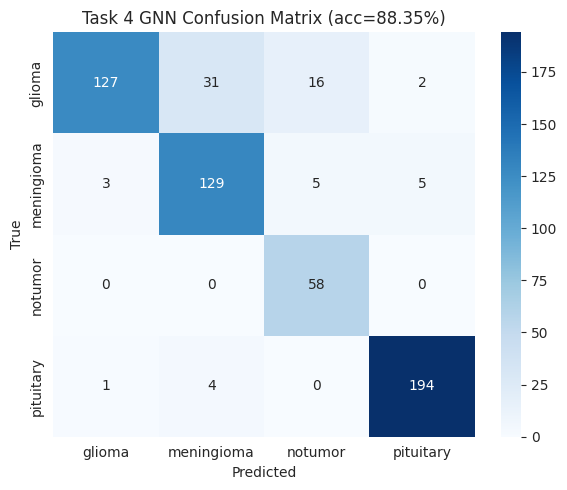

In [8]:
class_weights_arr = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=labels_trainval)
class_weights_final = torch.tensor(class_weights_arr, dtype=torch.float32).to(device)

final_train_idx, final_val_idx = train_test_split(
    np.arange(len(BEST_GRAPHS)), test_size=0.1, stratify=labels_trainval, random_state=SEED
)
final_train_graphs = [BEST_GRAPHS[i] for i in final_train_idx]
final_val_graphs = [BEST_GRAPHS[i] for i in final_val_idx]

if BEST_BALANCED_SAMPLER:
    final_sampler = make_balanced_sampler(final_train_graphs)
    final_train_loader = PyGDataLoader(final_train_graphs, batch_size=BATCH_SIZE, sampler=final_sampler)
else:
    final_train_loader = PyGDataLoader(final_train_graphs, batch_size=BATCH_SIZE, shuffle=True)
final_val_loader = PyGDataLoader(final_val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader = PyGDataLoader(BEST_GRAPHS_TEST, batch_size=BATCH_SIZE, shuffle=False)

fresh_block = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
TRAINABLE_BLOCK.load_state_dict(list(fresh_block.children())[5].state_dict())
TRAINABLE_BLOCK.to(device)

final_model = RobustBrainTumorGNN(
    conv_type=BEST_CONV_TYPE, num_layers=BEST_NUM_LAYERS, hidden_channels=BEST_HIDDEN,
    dropout=BEST_DROPOUT, use_batchnorm=BEST_BATCHNORM,
).to(device)

final_model, final_log = train_gnn(
    final_model, final_train_loader, final_val_loader, class_weights_final,
    min_epochs=MIN_EPOCHS, max_epochs=MAX_EPOCHS, patience=PATIENCE,
    lr=BEST_LR, backbone_lr=BEST_BACKBONE_LR, use_scheduler=BEST_SCHEDULER,
    use_class_weights=BEST_CLASS_WEIGHTS_FLAG, tag="[final]",
)
pd.DataFrame(final_log).to_csv("GNN_task4_final_history.csv", index=False)
torch.save(dict(gnn=final_model.state_dict(), backbone=TRAINABLE_BLOCK.state_dict()),
           "GNN_task4_best_model.pth")


@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        x = featurize_batch(batch, train_mode=False)
        out = model(x, batch.edge_index, batch.edge_attr, batch.batch)
        probs = F.softmax(out, dim=1).cpu().numpy()
        all_probs.append(probs); all_labels.append(batch.y.cpu().numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


gnn4_test_probs, gnn4_y_true = predict_all(final_model, test_loader, device)
gnn4_y_pred = np.argmax(gnn4_test_probs, axis=1)
gnn4_test_acc = accuracy_score(gnn4_y_true, gnn4_y_pred)
gnn4_filepaths = [g.filepath for g in BEST_GRAPHS_TEST]

print(f"\nFinal Task 4 GNN held-out test accuracy: {gnn4_test_acc:.4f}")
report_dict = classification_report(gnn4_y_true, gnn4_y_pred, target_names=CLASSES, output_dict=True, zero_division=0)
print(classification_report(gnn4_y_true, gnn4_y_pred, target_names=CLASSES, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(gnn4_y_true, gnn4_y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(f"Task 4 GNN Confusion Matrix (acc={gnn4_test_acc:.2%})")
plt.tight_layout(); plt.savefig("GNN_task4_confusion_matrix.png", dpi=120); plt.show()


## 9. Significance Test vs. Best Baseline (ViT)

Same filepath-based merge as Task 2/3 (row order isn't guaranteed to match
across notebooks even with identical dedup logic).


In [9]:
CNN_PREDS_PATH = "/kaggle/input/notebooks/meghlabiswas1/vit-cse475/vit_test_predictions.csv"  # <-- update path

if os.path.exists(CNN_PREDS_PATH):
    vit_df = pd.read_csv(CNN_PREDS_PATH)  # columns: filepath, y_true, y_pred

    gnn_df = pd.DataFrame({
        "filepath": gnn4_filepaths,
        "gnn_y_true": gnn4_y_true,
        "gnn_y_pred": gnn4_y_pred,
    })

    merged = gnn_df.merge(vit_df, on="filepath", how="inner", suffixes=("_gnn", "_vit"))
    n_gnn, n_vit, n_merged = len(gnn_df), len(vit_df), len(merged)
    if n_merged < min(n_gnn, n_vit):
        print(f"WARNING: only {n_merged} images matched by filepath "
              f"(GNN test set: {n_gnn}, ViT test set: {n_vit}).")

    label_mismatch = (merged["gnn_y_true"] != merged["y_true"]).sum()
    if label_mismatch > 0:
        print(f"WARNING: {label_mismatch} matched images have different true labels between notebooks.")

    gnn_y_true_aligned = merged["gnn_y_true"].to_numpy()
    gnn_y_pred_aligned = merged["gnn_y_pred"].to_numpy()
    cnn_y_pred_aligned = merged["y_pred"].to_numpy()

    cnn_correct = (cnn_y_pred_aligned == gnn_y_true_aligned)
    gnn_correct = (gnn_y_pred_aligned == gnn_y_true_aligned)

    both_correct = np.sum(cnn_correct & gnn_correct)
    cnn_only = np.sum(cnn_correct & ~gnn_correct)
    gnn_only = np.sum(~cnn_correct & gnn_correct)
    both_wrong = np.sum(~cnn_correct & ~gnn_correct)

    table = [[both_correct, cnn_only], [gnn_only, both_wrong]]
    result = mcnemar(table, exact=(cnn_only + gnn_only < 25))
    print(f"\nMcNemar's test on {n_merged} matched images:")
    print(pd.DataFrame(table, index=["GNN correct", "GNN wrong"], columns=["CNN correct", "CNN wrong"]))
    print(f"\nstatistic={result.statistic:.4f}, p-value={result.pvalue:.4f}")
    print("Significant at alpha=0.05" if result.pvalue < 0.05 else "Not significant at alpha=0.05")

    sig_results = {"statistic": float(result.statistic), "p_value": float(result.pvalue), "n_matched": int(n_merged)}
    with open("GNN_task4_significance_vs_vit.json", "w") as f:
        json.dump(sig_results, f, indent=2)
else:
    print(f"ViT predictions file not found at {CNN_PREDS_PATH} -- update the path to run this comparison.")
    sig_results = None


ViT predictions file not found at /kaggle/input/notebooks/meghlabiswas1/vit-cse475/vit_test_predictions.csv -- update the path to run this comparison.


## 10. Explainability — GNNExplainer, Superpixel Grad-CAM, Superpixel LIME

Same three methods as Task 3, shown for one correct and one wrong
prediction. Adapted only where the new architecture requires it: features
now come from `featurize_batch` (live backbone) instead of being stored on
the graph, and `edge_attr` is 5-d instead of a scalar.


In [10]:
def get_single_graph_features(data):
    '''Featurizes one Data object (adds batch dim of 1) using the trained,
    now-frozen-for-eval backbone.'''
    data = data.clone()
    loader = PyGDataLoader([data], batch_size=1, shuffle=False)
    batch = next(iter(loader)).to(device)
    with torch.no_grad():
        x = featurize_batch(batch, train_mode=False)
    return x, batch


explainer = Explainer(
    model=final_model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=dict(mode="multiclass_classification", task_level="graph", return_type="raw"),
)

def gnn_explain(data):
    x, batch = get_single_graph_features(data)
    explanation = explainer(
        x=x, edge_index=batch.edge_index, edge_attr=batch.edge_attr,
        batch=torch.zeros(x.shape[0], dtype=torch.long, device=device),
    )
    return explanation.node_mask.sum(dim=1).cpu().numpy()


correct_idx = next(i for i in range(len(BEST_GRAPHS_TEST)) if gnn4_y_pred[i] == gnn4_y_true[i])
wrong_idx = next((i for i in range(len(BEST_GRAPHS_TEST)) if gnn4_y_pred[i] != gnn4_y_true[i]), None)
print("GNNExplainer target indices -- correct:", correct_idx, "| wrong:", wrong_idx)


GNNExplainer target indices -- correct: 1 | wrong: 0


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


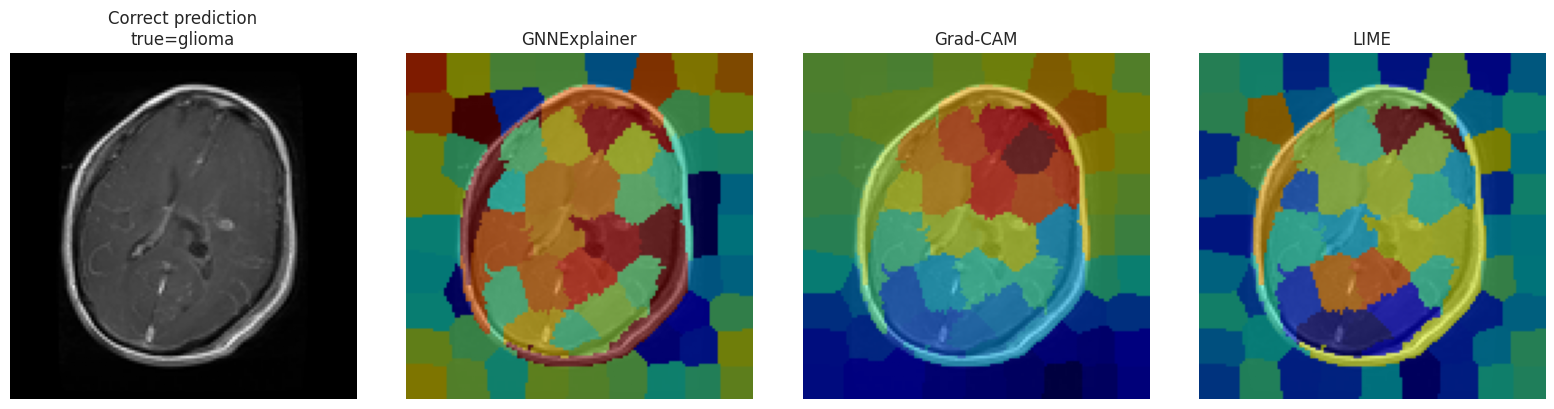

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


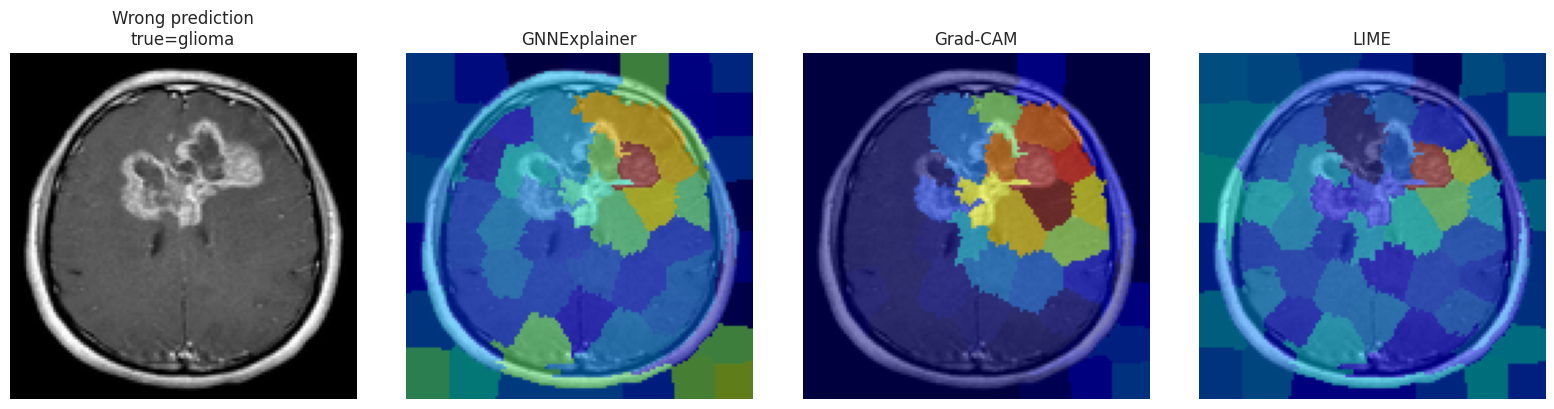

In [11]:
# --- Superpixel-level Grad-CAM ---
def superpixel_gradcam(model, data, pred_index=None):
    model.eval()
    x, batch = get_single_graph_features(data)
    x.requires_grad_(True)
    b = torch.zeros(x.shape[0], dtype=torch.long, device=device)

    h = x
    for i in range(model.num_layers - 1):
        if model.conv_type == "gat":
            h = model.convs[i](h, batch.edge_index, edge_attr=batch.edge_attr)
        else:
            h = model.convs[i](h, batch.edge_index, edge_weight=batch.edge_attr[:, 0])
        h = model.bns[i](h)
        h = F.relu(h)
    if model.conv_type == "gat":
        last_conv_out = model.convs[-1](h, batch.edge_index, edge_attr=batch.edge_attr)
    else:
        last_conv_out = model.convs[-1](h, batch.edge_index, edge_weight=batch.edge_attr[:, 0])
    last_conv_out.retain_grad()
    h_final = F.relu(model.bns[-1](last_conv_out))

    x_mean = global_mean_pool(h_final, b)
    x_max = global_max_pool(h_final, b)
    x_attn = model.attn_pool(h_final, b)
    pooled = torch.cat([x_mean, x_max, x_attn], dim=1)
    logits = model.classifier(pooled)
    if pred_index is None:
        pred_index = logits.argmax(dim=1).item()

    model.zero_grad()
    logits[0, pred_index].backward()

    grads = last_conv_out.grad
    weights = grads.mean(dim=0)
    cam = torch.relu((weights * last_conv_out).sum(dim=1))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam.detach().cpu().numpy(), pred_index


# --- Superpixel-level LIME ---
# Perturb by zeroing out random subsets of superpixels (nodes), observe the
# change in predicted probability for the model's own class, then fit a
# weighted linear surrogate -- the coefficients are per-superpixel importance.
def superpixel_lime(model, data, pred_index=None, n_samples=200, kernel_width_frac=0.25):
    model.eval()
    x0, batch = get_single_graph_features(data)
    n_nodes = x0.shape[0]
    b = torch.zeros(n_nodes, dtype=torch.long, device=device)

    with torch.no_grad():
        base_out = model(x0, batch.edge_index, batch.edge_attr, b)
        if pred_index is None:
            pred_index = base_out.argmax(dim=1).item()

    masks = np.random.binomial(1, 0.5, size=(n_samples, n_nodes)).astype(np.float32)
    masks[0] = 1.0  # include the "everything present" sample
    probs = np.zeros(n_samples, dtype=np.float32)
    with torch.no_grad():
        for s in range(n_samples):
            mask_t = torch.tensor(masks[s], device=device).unsqueeze(-1)
            x_masked = x0 * mask_t
            out = model(x_masked, batch.edge_index, batch.edge_attr, b)
            probs[s] = F.softmax(out, dim=1)[0, pred_index].item()

    distances = np.sum(masks != 1.0, axis=1) / n_nodes
    kernel_width = kernel_width_frac
    weights = np.sqrt(np.exp(-(distances ** 2) / (kernel_width ** 2)))

    from sklearn.linear_model import Ridge
    surrogate = Ridge(alpha=1.0)
    surrogate.fit(masks, probs, sample_weight=weights)
    importance = surrogate.coef_
    importance = (importance - importance.min()) / (importance.max() - importance.min() + 1e-8)
    return importance, pred_index


def plot_explanations(idx, title_prefix):
    data = BEST_GRAPHS_TEST[idx]
    segments = data.segments
    img = Image.open(data.filepath).convert("L").resize(GRAPH_IMG_SIZE, Image.LANCZOS)
    img_arr = np.asarray(img, dtype=np.float32) / 255.0
    n_real = data.n_real_nodes

    gnn_scores = gnn_explain(data)[:n_real]
    cam_scores, cam_pred = superpixel_gradcam(final_model, data)
    cam_scores = cam_scores[:n_real]
    lime_scores, lime_pred = superpixel_lime(final_model, data)
    lime_scores = lime_scores[:n_real]

    def score_to_map(scores):
        m = np.zeros_like(img_arr)
        for seg_id in range(n_real):
            m[segments == seg_id] = scores[seg_id]
        return m

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img_arr, cmap="gray"); axes[0].set_title(f"{title_prefix}\ntrue={CLASSES[data.y.item()]}"); axes[0].axis("off")
    for ax, scores, name in zip(axes[1:], [gnn_scores, cam_scores, lime_scores], ["GNNExplainer", "Grad-CAM", "LIME"]):
        ax.imshow(img_arr, cmap="gray")
        ax.imshow(score_to_map(scores), cmap="jet", alpha=0.5)
        ax.set_title(name); ax.axis("off")
    plt.tight_layout()
    fname = f"GNN_task4_explain_{title_prefix.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=120); plt.show()


plot_explanations(correct_idx, "Correct prediction")
if wrong_idx is not None:
    plot_explanations(wrong_idx, "Wrong prediction")


## 11. Ablation — CNN vs. CNN+GNN (repeated on the new pipeline)

Task 3's version of this ablation used **frozen** CNN features for both
models and found the GCN's contribution non-significant (p=0.243). This
repeats the same comparison, but both models now share the exact same
**fine-tuned** backbone and richer graph the rest of this notebook uses —
so this checks whether the graph structure earns its keep once the
features it's built on are no longer the bottleneck.

- **Model A (CNN-only)**: global-average-pooled fine-tuned backbone
  features → small MLP classifier. No graph at all.
- **Model B (CNN+GNN)**: this notebook's `RobustBrainTumorGNN` (GAT/GCN per
  the sweep winner, attention pooling, virtual node) on top of the same
  backbone.

Both share backbone weights during this comparison so the only difference
being measured is graph structure vs. none — not how much the backbone was
trained.


Extracting global (whole-image) features from the fine-tuned backbone for Model A...
  500/5652 done
  1000/5652 done
  1500/5652 done
  2000/5652 done
  2500/5652 done
  3000/5652 done
  3500/5652 done
  4000/5652 done
  4500/5652 done
  5000/5652 done
  5500/5652 done
  500/575 done
[Model A] epoch 1/60 - loss: 0.4036 acc: 0.8657 - val_loss: 0.2193 val_acc: 0.9293
[Model A] epoch 2/60 - loss: 0.2126 acc: 0.9294 - val_loss: 0.1999 val_acc: 0.9240
[Model A] epoch 3/60 - loss: 0.1751 acc: 0.9392 - val_loss: 0.1890 val_acc: 0.9311
[Model A] epoch 4/60 - loss: 0.1556 acc: 0.9440 - val_loss: 0.1838 val_acc: 0.9311
[Model A] epoch 5/60 - loss: 0.1400 acc: 0.9471 - val_loss: 0.2007 val_acc: 0.9311
[Model A] epoch 6/60 - loss: 0.1270 acc: 0.9530 - val_loss: 0.2649 val_acc: 0.8958
[Model A] epoch 7/60 - loss: 0.1329 acc: 0.9489 - val_loss: 0.1956 val_acc: 0.9293
[Model A] epoch 8/60 - loss: 0.1247 acc: 0.9544 - val_loss: 0.2055 val_acc: 0.9187
[Model A] epoch 9/60 - loss: 0.1185 acc: 0.9542 - 

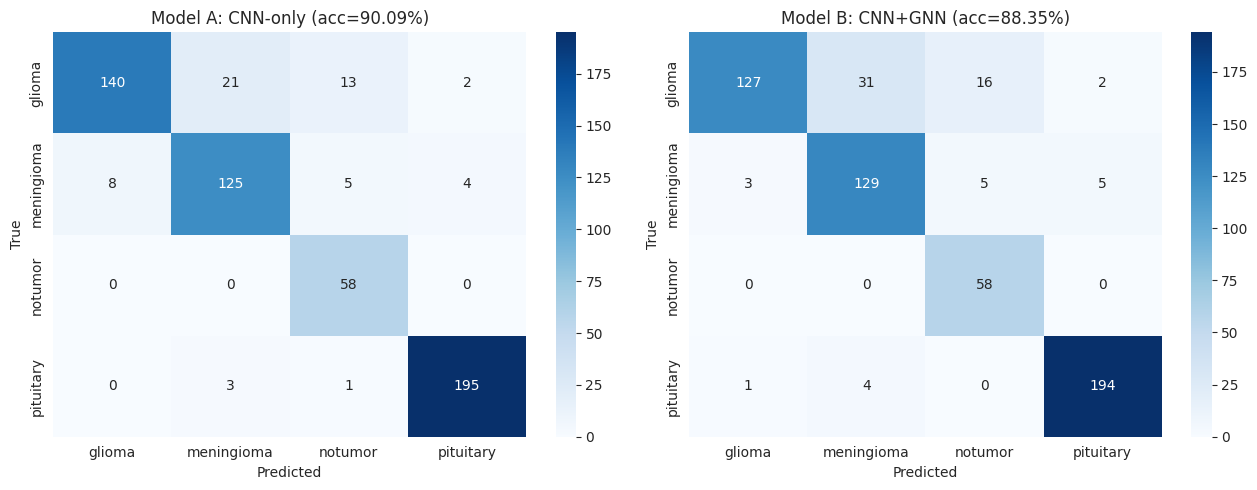

In [12]:
class CNNOnlyClassifier(nn.Module):
    def __init__(self, in_dim=CNN_FEATURE_DIM, hidden=128, num_classes=NUM_CLASSES, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(hidden, num_classes),
        )
    def forward(self, x):
        return self.net(x)


@torch.no_grad()
def extract_global_feature(filepath, train_mode=False):
    img = Image.open(filepath).convert("L").resize(GRAPH_IMG_SIZE, Image.LANCZOS)
    img_arr = np.asarray(img, dtype=np.float32) / 255.0
    t = torch.tensor(img_arr).unsqueeze(0).unsqueeze(0).to(device)
    fmap = backbone_feature_map(t, train_mode=train_mode)
    return fmap.mean(dim=(2, 3))[0].cpu().numpy()


def build_global_feature_dataset(df, backbone_train_mode=False):
    X, y = [], []
    for i, row in df.iterrows():
        X.append(extract_global_feature(row["filepath"], train_mode=backbone_train_mode))
        y.append(CLASS_TO_IDX[row["class"]])
        if (i + 1) % 500 == 0:
            print(f"  {i + 1}/{len(df)} done")
    return np.stack(X).astype(np.float32), np.array(y, dtype=np.int64)


def train_one_epoch_mlp(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def validate_mlp(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out, yb)
        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return total_loss / total, correct / total

def train_cnn_only(model, train_loader, val_loader, class_weights, min_epochs, max_epochs, patience, tag=""):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=patience, min_epochs=min_epochs)
    log = []
    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch_mlp(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate_mlp(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        log.append(dict(epoch=epoch, train_loss=train_loss, train_acc=train_acc, val_loss=val_loss, val_acc=val_acc))
        print(f"{tag} epoch {epoch}/{max_epochs} - loss: {train_loss:.4f} acc: {train_acc:.4f} - val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")
        def snapshot():
            return copy.deepcopy(model.state_dict())
        early_stopping.step(epoch, val_loss, snapshot)
        if early_stopping.should_stop:
            print(f"{tag} early stopping at epoch {epoch}")
            break
    if early_stopping.best_state is not None:
        model.load_state_dict(early_stopping.best_state)
    return model, log


# Use the ALREADY fine-tuned backbone (from Section 8's final GNN training)
# for both models -- isolates "graph vs. no graph" as the only difference.
print("Extracting global (whole-image) features from the fine-tuned backbone for Model A...")
X_trainval, y_trainval_global = build_global_feature_dataset(df_trainval, backbone_train_mode=False)
X_test, y_test_global = build_global_feature_dataset(df_test, backbone_train_mode=False)

a_train_idx, a_val_idx = train_test_split(np.arange(len(X_trainval)), test_size=0.1, stratify=y_trainval_global, random_state=SEED)
a_train_ds = torch.utils.data.TensorDataset(torch.tensor(X_trainval[a_train_idx]), torch.tensor(y_trainval_global[a_train_idx]))
a_val_ds = torch.utils.data.TensorDataset(torch.tensor(X_trainval[a_val_idx]), torch.tensor(y_trainval_global[a_val_idx]))
a_train_loader = torch.utils.data.DataLoader(a_train_ds, batch_size=BATCH_SIZE, shuffle=True)
a_val_loader = torch.utils.data.DataLoader(a_val_ds, batch_size=BATCH_SIZE, shuffle=False)

class_weights_a = torch.tensor(
    compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_trainval_global[a_train_idx]),
    dtype=torch.float32,
).to(device)

final_model_A = CNNOnlyClassifier().to(device)
final_model_A, log_A = train_cnn_only(
    final_model_A, a_train_loader, a_val_loader, class_weights_a,
    min_epochs=MIN_EPOCHS, max_epochs=MAX_EPOCHS, patience=PATIENCE, tag="[Model A]",
)

# --- Model B: this notebook's final GNN (already trained in Section 8) ---
final_model_B = final_model
cnn_gnn_y_pred = gnn4_y_pred
cnn_gnn_y_true = gnn4_y_true
modelB_acc = gnn4_test_acc

final_model_A.eval()
with torch.no_grad():
    cnn_only_test_probs = F.softmax(final_model_A(torch.tensor(X_test).to(device)), dim=1).cpu().numpy()
cnn_only_y_pred = np.argmax(cnn_only_test_probs, axis=1)
cnn_only_y_true = y_test_global
modelA_acc = accuracy_score(cnn_only_y_true, cnn_only_y_pred)

print(f"\nModel A (CNN-only, fine-tuned backbone) held-out test accuracy: {modelA_acc:.4f}")
print(f"Model B (CNN+GNN, this notebook's final model) held-out test accuracy: {modelB_acc:.4f}")

assert np.array_equal(cnn_only_y_true, cnn_gnn_y_true), "Model A and Model B must be evaluated on the identical test set"

np.save("GNN_task4_ModelA_test_predictions.npy", cnn_only_y_pred)
np.save("GNN_task4_ModelB_test_predictions.npy", cnn_gnn_y_pred)
np.save("GNN_task4_ablation_test_labels.npy", cnn_gnn_y_true)

a_correct = (cnn_only_y_pred == cnn_gnn_y_true)
b_correct = (cnn_gnn_y_pred == cnn_gnn_y_true)
both = int(np.sum(a_correct & b_correct))
a_only = int(np.sum(a_correct & ~b_correct))
b_only = int(np.sum(~a_correct & b_correct))
neither = int(np.sum(~a_correct & ~b_correct))
ab_table = [[both, a_only], [b_only, neither]]
ab_result = mcnemar(ab_table, exact=(a_only + b_only < 25))
print(f"\nMcNemar's test, Model A (CNN-only) vs Model B (CNN+GNN):")
print(pd.DataFrame(ab_table, index=["ModelB correct", "ModelB wrong"], columns=["ModelA correct", "ModelA wrong"]))
print(f"statistic={ab_result.statistic:.4f}, p-value={ab_result.pvalue:.4f}")
print("Significant at alpha=0.05" if ab_result.pvalue < 0.05 else "Not significant at alpha=0.05")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(confusion_matrix(cnn_only_y_true, cnn_only_y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title(f"Model A: CNN-only (acc={modelA_acc:.2%})"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
sns.heatmap(confusion_matrix(cnn_gnn_y_true, cnn_gnn_y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title(f"Model B: CNN+GNN (acc={modelB_acc:.2%})"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.tight_layout(); plt.savefig("GNN_task4_ablation_confusion_matrices.png", dpi=120); plt.show()

ablation_summary = {
    "modelA_cnn_only_acc": float(modelA_acc), "modelB_cnn_gnn_acc": float(modelB_acc),
    "mcnemar_statistic": float(ab_result.statistic), "mcnemar_pvalue": float(ab_result.pvalue),
}


## 12. Results Summary

In [13]:
VIT_BASELINE_ACC = 0.9497     # exact ViT test accuracy (from Task 3 notebook)
TASK2_GCN_ACC = 0.7513        # original hand-crafted-feature GCN (Task 2)
TASK3_GCN_ACC = 0.7583        # tuned hand-crafted-feature GCN (Task 3)

summary = {
    "model_name": f"GNN_task4_{BEST_NAME}",
    "sweep_results": sweep_df.to_dict(orient="records"),
    "cv_mean_acc": cv_df["val_acc"].mean(), "cv_std_acc": cv_df["val_acc"].std(),
    "cv_mean_f1_macro": cv_df["f1_macro"].mean(), "cv_std_f1_macro": cv_df["f1_macro"].std(),
    "final_test_accuracy": gnn4_test_acc,
    "final_test_f1_macro": report_dict["macro avg"]["f1-score"],
    "task2_gcn_test_accuracy": TASK2_GCN_ACC,
    "task3_gcn_test_accuracy": TASK3_GCN_ACC,
    "vit_baseline_accuracy": VIT_BASELINE_ACC,
    "improvement_over_task2_gcn": gnn4_test_acc - TASK2_GCN_ACC,
    "improvement_over_task3_gcn": gnn4_test_acc - TASK3_GCN_ACC,
    "gap_to_vit": gnn4_test_acc - VIT_BASELINE_ACC,
    "significance_vs_vit": sig_results,
    "ablation_cnn_vs_cnngnn": ablation_summary,
}
with open("GNN_task4_results_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("=== Task 4 Final Summary ===")
print(f"Task 2 GCN (hand-crafted feats):     {TASK2_GCN_ACC:.2%}")
print(f"Task 3 GCN (tuned, hand-crafted):    {TASK3_GCN_ACC:.2%}")
print(f"Task 4 GNN ({BEST_NAME}):")
print(f"  -> {gnn4_test_acc:.2%}")
print(f"Improvement over Task 2 GCN: {(gnn4_test_acc - TASK2_GCN_ACC):+.2%}")
print(f"Improvement over Task 3 GCN: {(gnn4_test_acc - TASK3_GCN_ACC):+.2%}")
print(f"ViT baseline:                {VIT_BASELINE_ACC:.2%}")
print(f"Remaining gap to ViT:        {(gnn4_test_acc - VIT_BASELINE_ACC):+.2%}")
print(f"\nAblation -- Model A (CNN-only, fine-tuned):  {modelA_acc:.2%}")
print(f"Ablation -- Model B (CNN+GNN, this notebook): {modelB_acc:.2%}")
print(f"Ablation McNemar p-value: {ab_result.pvalue:.4f}")


=== Task 4 Final Summary ===
Task 2 GCN (hand-crafted feats):     75.13%
Task 3 GCN (tuned, hand-crafted):    75.83%
Task 4 GNN (no_virtual_node):
  -> 88.35%
Improvement over Task 2 GCN: +13.22%
Improvement over Task 3 GCN: +12.52%
ViT baseline:                94.97%
Remaining gap to ViT:        -6.62%

Ablation -- Model A (CNN-only, fine-tuned):  90.09%
Ablation -- Model B (CNN+GNN, this notebook): 88.35%
Ablation McNemar p-value: 0.1443
